# Math 189 Final Project Code

## Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

df = pd.read_csv("full_housing_data.csv")

df.head()

,Unnamed: 0,address,addressZipcode,addressStreet,area,baths,beds,latitude,longitude,monthly_rent,...,ucsd_car_time,ucsd_transit_dist,ucsd_transit_time,nearest_grocery,grocery_car_dist,grocery_car_time,coast_dist_km,medNeighborhoodIncome,zip_code,avg_crime
0,0,"Vadara West, 2724 El Cajon Blvd #402, San Dieg...",92104,2724 El Cajon Blvd #402,795.0,1.0,1.0,32.755623,-117.134330,2995,...,20 mins,27.6 km,1 hour 8 mins,Whole Foods Market,2.9 km,8 mins,11.041507,92862,92104.0,1.336323
1,1,"Fashion Terrace, 6888 Friars Rd, San Diego, CA...",92108,6888 Friars Rd,1038.0,2.0,2.0,32.769010,-117.172070,3100,...,16 mins,19.4 km,45 mins,Whole Foods Market,4.1 km,7 mins,7.417457,101704,92108.0,21.679286
2,2,"Esprit Villas, 9830 Reagan Rd #60b404513, San ...",92126,9830 Reagan Rd #60b404513,950.0,2.0,2.0,32.909718,-117.147400,2895,...,17 mins,14.6 km,43 mins,H Mart,3.5 km,10 mins,10.119282,123232,92126.0,0.744286
3,3,"The Royal of Rancho Penasquitos, 9808 Paseo Mo...",92129,9808 Paseo Montalban #27,982.0,2.0,2.0,32.962887,-117.117490,3095,...,17 mins,23.6 km,1 hour 4 mins,H Mart,6.3 km,9 mins,13.790490,152626,92129.0,0.508201
4,4,"10632 Quill Ct, San Diego, CA 92126",92126,10632 Quill Ct,1943.0,4.0,3.0,32.897533,-117.165726,5680,...,15 mins,13.9 km,1 hour 0 mins,H Mart,7.2 km,14 mins,8.191808,123232,92126.0,0.744286


We observe basic attributes about our dataset below.

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(1613, 24)
Unnamed: 0                 int64
address                   object
addressZipcode             int64
addressStreet             object
area                     float64
baths                    float64
beds                     float64
latitude                 float64
longitude                float64
monthly_rent               int64
nearest_transit           object
transit_walk_dist         object
transit_walk_time         object
ucsd_car_dist             object
ucsd_car_time             object
ucsd_transit_dist         object
ucsd_transit_time         object
nearest_grocery           object
grocery_car_dist          object
grocery_car_time          object
coast_dist_km            float64
medNeighborhoodIncome      int64
zip_code                 float64
avg_crime                float64
dtype: object
        Unnamed: 0  addressZipcode          area        baths         beds  \
count  1613.000000     1613.000000   1613.000000  1613.000000  1613.000000   
mean    806.000000    92104

We now check for any null values that may distort our findings.

In [3]:
print(df.isnull().sum())

Unnamed: 0                 0
address                    0
addressZipcode             0
addressStreet              0
area                       0
baths                      0
beds                       0
latitude                   0
longitude                  0
monthly_rent               0
nearest_transit            0
transit_walk_dist          0
transit_walk_time          0
ucsd_car_dist              0
ucsd_car_time              0
ucsd_transit_dist        124
ucsd_transit_time        124
nearest_grocery            0
grocery_car_dist           0
grocery_car_time           0
coast_dist_km              0
medNeighborhoodIncome      0
zip_code                  22
avg_crime                 22
dtype: int64


As can be seen, variables ucsd_transit_dist, ucsd_transit_time, zip_code, and avg_crime have null values. We remove observations from our dataset in which this is the case. After, we confirm the accuracy of our action by printing the sum of null observations for each category. Since all are zero, our code is successful.

In [4]:
df = df.dropna(subset=['ucsd_transit_dist', 'ucsd_transit_time', 'zip_code', 'avg_crime'])
print(df.isnull().sum())

Unnamed: 0               0
address                  0
addressZipcode           0
addressStreet            0
area                     0
baths                    0
beds                     0
latitude                 0
longitude                0
monthly_rent             0
nearest_transit          0
transit_walk_dist        0
transit_walk_time        0
ucsd_car_dist            0
ucsd_car_time            0
ucsd_transit_dist        0
ucsd_transit_time        0
nearest_grocery          0
grocery_car_dist         0
grocery_car_time         0
coast_dist_km            0
medNeighborhoodIncome    0
zip_code                 0
avg_crime                0
dtype: int64


Now, we will check for significant outliers, innaccurate values for apartment attributes, and duplicates.

count     1467.000000
mean      5823.347648
std       6151.917866
min        615.000000
25%       2950.000000
50%       4225.000000
75%       6370.500000
max      85000.000000
Name: monthly_rent, dtype: float64

Listings under $500: 0
Listings over $10,000: 133

Zero bed listings: 0
Zero bath listings: 0
Zero area listings: 0

Duplicate addresses: 0


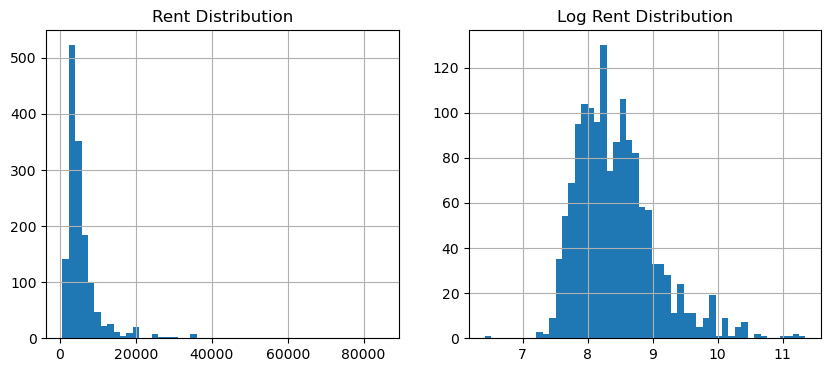

In [5]:
# Rent outliers
print(df['monthly_rent'].describe())
print(f"\nListings under $500: {len(df[df['monthly_rent'] < 500])}")
print(f"Listings over $10,000: {len(df[df['monthly_rent'] > 10000])}")

# Strange beds/baths/area values
print(f"\nZero bed listings: {len(df[df['beds'] == 0])}")
print(f"Zero bath listings: {len(df[df['baths'] == 0])}")
print(f"Zero area listings: {len(df[df['area'] == 0])}")

# Duplicates
print(f"\nDuplicate addresses: {df['addressStreet'].duplicated().sum()}")

# Rent distribution to visualize any more abnormalities
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['monthly_rent'].hist(bins=50)
plt.title('Rent Distribution')
plt.subplot(1,2,2)
np.log(df['monthly_rent']).hist(bins=50)
plt.title('Log Rent Distribution')
plt.show()

Since there are a few outliers, we will remove those. However, there are no strange values for apartment attributes nor duplicates.

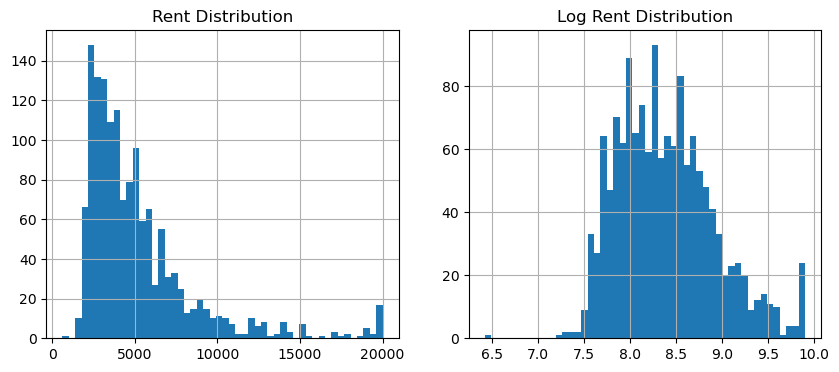

In [6]:
df = df[df['monthly_rent'] <= 20000]

# Rent distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['monthly_rent'].hist(bins=50)
plt.title('Rent Distribution')
plt.subplot(1,2,2)
np.log(df['monthly_rent']).hist(bins=50)
plt.title('Log Rent Distribution')
plt.show()

Some of the variables representing distances and travel times contain units such as "km" and "mins" stored as part of their string values. To prepare these variables for analysis, we remove the unit labels and convert the columns to numeric types.

In [7]:
df['ucsd_car_time'] = df['ucsd_car_time'].str.replace(' mins','').astype(float)
df['ucsd_transit_dist'] = df['ucsd_transit_dist'].str.replace(' km','').astype(float)
df['transit_walk_dist'] = df['transit_walk_dist'].str.replace(' km','').astype(float)
df['ucsd_car_dist'] = df['ucsd_car_dist'].str.replace(' km','').astype(float)
df['grocery_car_dist'] = df['grocery_car_dist'].str.replace(' km','').astype(float)

Some variables, such as ucsd_transit_time and transit_walk_time, include travel times expressed in both hours and minutes. To make these variables consistent and usable for analysis, we create a function that converts all travel times into total minutes. 

In [8]:
def convert(input):
    if "hour" in input:
        return (int(input.split()[0])*60 + int(input.split()[2]))
    else:
        return (int(input.split()[0]))

#Apply it on the respective columns.
df['ucsd_transit_time'] = df['ucsd_transit_time'].apply(convert)
df['transit_walk_time'] = df['transit_walk_time'].apply(convert)
df['grocery_car_time'] = df['grocery_car_time'].apply(convert)
df.head()

,Unnamed: 0,address,addressZipcode,addressStreet,area,baths,beds,latitude,longitude,monthly_rent,...,ucsd_car_time,ucsd_transit_dist,ucsd_transit_time,nearest_grocery,grocery_car_dist,grocery_car_time,coast_dist_km,medNeighborhoodIncome,zip_code,avg_crime
0,0,"Vadara West, 2724 El Cajon Blvd #402, San Dieg...",92104,2724 El Cajon Blvd #402,795.0,1.0,1.0,32.755623,-117.134330,2995,...,20.0,27.6,68,Whole Foods Market,2.9,8,11.041507,92862,92104.0,1.336323
1,1,"Fashion Terrace, 6888 Friars Rd, San Diego, CA...",92108,6888 Friars Rd,1038.0,2.0,2.0,32.769010,-117.172070,3100,...,16.0,19.4,45,Whole Foods Market,4.1,7,7.417457,101704,92108.0,21.679286
2,2,"Esprit Villas, 9830 Reagan Rd #60b404513, San ...",92126,9830 Reagan Rd #60b404513,950.0,2.0,2.0,32.909718,-117.147400,2895,...,17.0,14.6,43,H Mart,3.5,10,10.119282,123232,92126.0,0.744286
3,3,"The Royal of Rancho Penasquitos, 9808 Paseo Mo...",92129,9808 Paseo Montalban #27,982.0,2.0,2.0,32.962887,-117.117490,3095,...,17.0,23.6,64,H Mart,6.3,9,13.790490,152626,92129.0,0.508201
4,4,"10632 Quill Ct, San Diego, CA 92126",92126,10632 Quill Ct,1943.0,4.0,3.0,32.897533,-117.165726,5680,...,15.0,13.9,60,H Mart,7.2,14,8.191808,123232,92126.0,0.744286


## Modeling

We note that distances are measured in kilometers (km) and travel times are measured in minutes.

Text(0, 0.5, 'Monthly Rent')

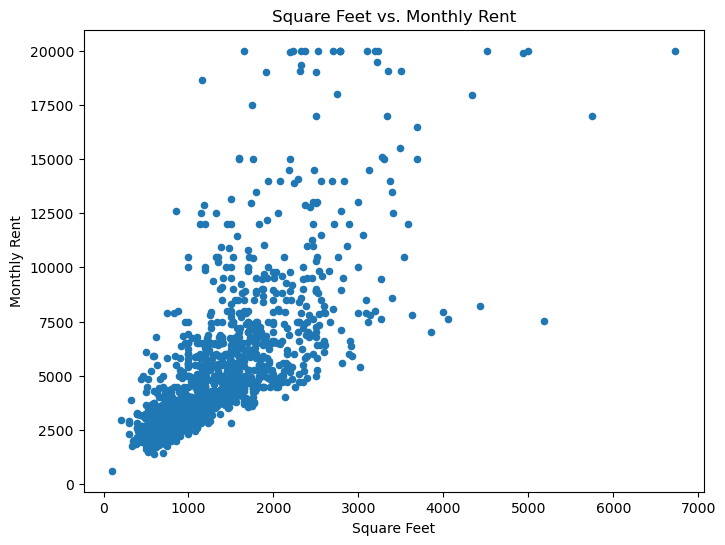

In [9]:
ax = df.plot(kind='scatter',x='area',y='monthly_rent',figsize=(8,6),title='Square Feet vs. Monthly Rent')
ax.set_xlabel('Square Feet')
ax.set_ylabel('Monthly Rent')

There is a strong positive relationship between square footage and monthly rent. The majority of rentals in our dataset are over 2,500 dollars/month, which is above the national average of approximately 2,000 dollars/month for all property types.

Text(0, 0.5, 'Monthly Rent')

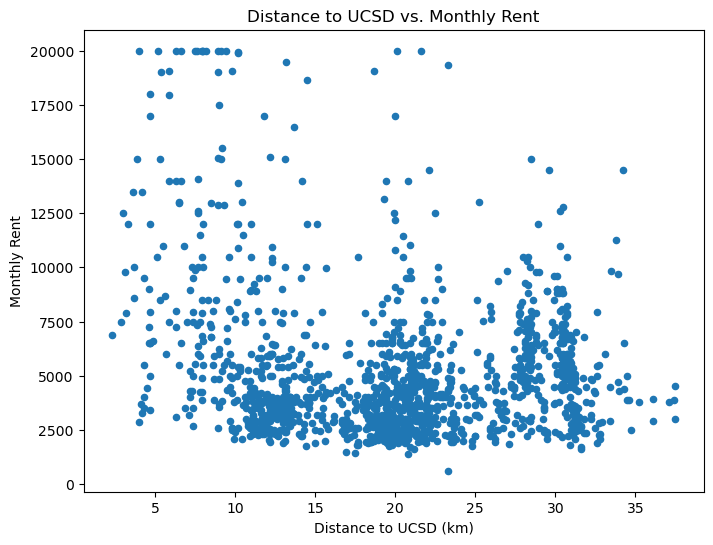

In [10]:
ax = df.plot(kind='scatter',x='ucsd_car_dist',y='monthly_rent',figsize=(8,6),title='Distance to UCSD vs. Monthly Rent')
ax.set_xlabel('Distance to UCSD (km)')
ax.set_ylabel('Monthly Rent')

Most points are clustered at lower rents (~2,500-5,000 dollars/month) regardless of distance. There's no strong clear trend of rent decreasing with further distance. The majority of rentals are concentrated within 35 kilometers from UCSD.

Text(0, 0.5, 'Monthly Rent')

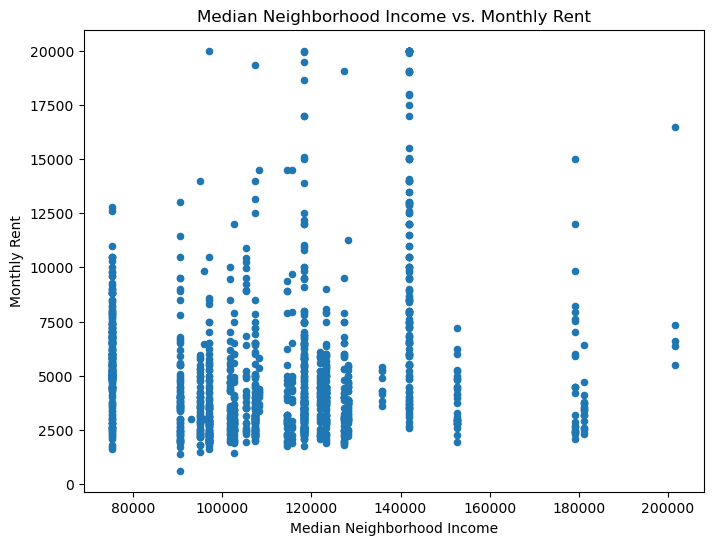

In [11]:
ax = df.plot(kind='scatter',x='medNeighborhoodIncome',y='monthly_rent',figsize=(8,6),title='Median Neighborhood Income vs. Monthly Rent')
ax.set_xlabel('Median Neighborhood Income')
ax.set_ylabel('Monthly Rent')

There's a slight upward trend. Neighborhoods with higher median income tend to have more higher-rent listings. Outliers exist at very high rents (15,000 dollars-20,000 dollars), typically in higher-income neighborhoods. The majority of rentals are concentrated in neighborhoods with median incomes between 80,000 dollars and 140,000.

This suggests other factors (like proximity to UCSD, property type, or amenities) also affect rent.

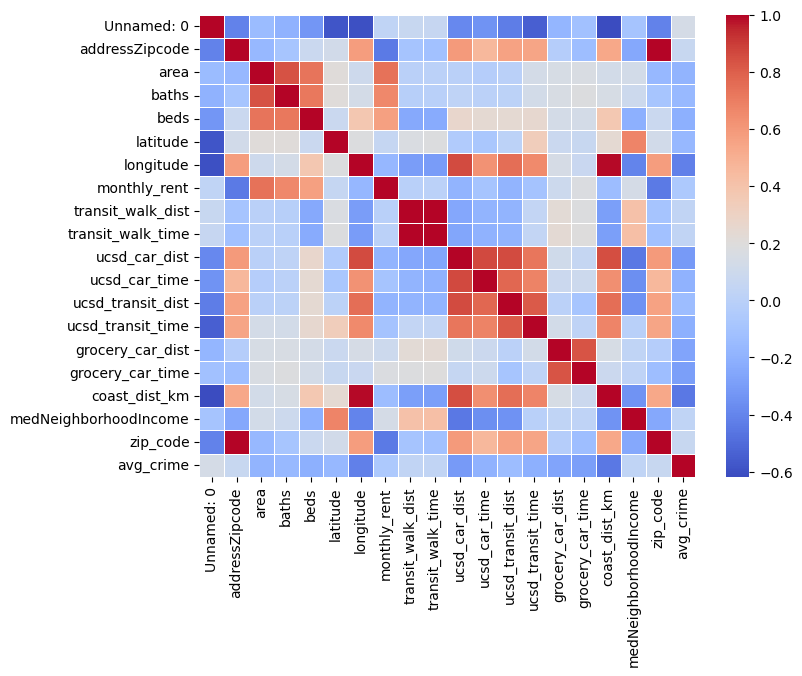

In [12]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,cmap='coolwarm',linewidths=0.5)
plt.show()

There is a strong positive correlation (orange/red blocks) between area, baths, beds, and monthly_rent. This confirms the idea that larger homes with more rooms cost more.
There is a strong positive correlation between longitude and coast distance. This implies that your longitudinal position is a primary driver of how far you are from the coast.


In [13]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

features = [
    "area",
    "baths",
    "beds",
    "ucsd_transit_time",
    "grocery_car_time",
    "medNeighborhoodIncome",
    "avg_crime"
]

X = df[features]
y = df["monthly_rent"]

X = sm.add_constant(X) #Constant

model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           monthly_rent   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     321.2
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          8.73e-288
Time:                        01:15:55   Log-Likelihood:                -12998.
No. Observations:                1435   AIC:                         2.601e+04
Df Residuals:                    1427   BIC:                         2.605e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    63.29

Our linear regression model explains about 62% of the variation in monthly rent. Rent is strongly driven by unit size (area, bedrooms, bathrooms). Transit time to UCSD is negatively associated with rent, indicating a "UCSD premium" - closer properties cost more. Car time however shows a positive coefficient. All predictors are statistically significant at the 0.01 level.

### Ridge Regression Model

Now that we've fit a linear regression model, we can also try a Ridge regression model. Ridge regression penalizes large coefficients and helps address potential multicollinearity, allowing us to check whether our findings are robust.

In [14]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled,y)
coefs = pd.Series(ridge.coef_,index=X.columns)
print(coefs)

const                       0.000000
area                     1815.418699
baths                     308.577344
beds                      608.675655
ucsd_transit_time        -730.944418
grocery_car_time          230.514553
medNeighborhoodIncome     308.429941
avg_crime                 213.539596
dtype: float64


The Ridge model produced coefficients with similar signs as the OLS model. In particular, UCSD transit time remained negative, confirming that apartments closer to UCSD tend to have higher rents.

Here, we compute the average monthly rent based on distance from UCSD. We classify properties as either within or beyond 30 minutes of transit time to UCSD and compare the average rents for each group.

In [15]:
df_near_ucsd = df[df.get('ucsd_transit_time')<=30]
df_far_ucsd = df[df.get('ucsd_transit_time')>30]
near_ucsd_rentAvg = df_near_ucsd.get('monthly_rent').mean()
far_ucsd_rentAvg = df_far_ucsd.get('monthly_rent').mean()
print("Rent near UCSD : $", near_ucsd_rentAvg)
print("Rent away from UCSD: $", far_ucsd_rentAvg)

Rent near UCSD : $ 7279.5875
Rent away from UCSD: $ 5009.9047970479705


It's costlier to live near UCSD as opposed to away from UCSD (by ~$2,000).

### Original Model Diagnostics

Before interpreting our model, we check whether the standard linear regression assumptions hold by examining the residuals.

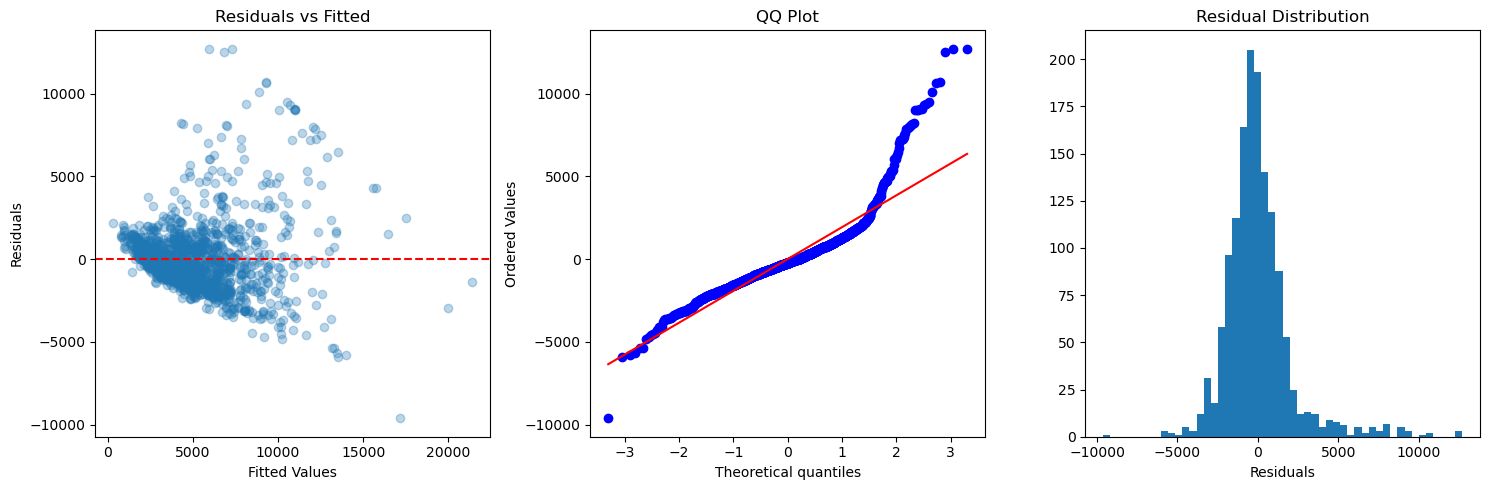

In [16]:
import scipy.stats as stats

# Fitted values and residuals
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuals vs Fitted values
axes[0].scatter(fitted, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# QQ Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

# Histogram of residuals
axes[2].hist(residuals, bins=50)
axes[2].set_xlabel('Residuals')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

Through our model diagnostics, several violations of linear regression assumptions were revealed through residual plots:

**Residuals vs Fitted:** There is a clear funnel shape — residuals spread out as fitted values increase. This indicates heteroscedasticity, meaning the model is less accurate for higher-priced rentals than lower-priced ones. This violates the constant variance assumption.

**QQ Plot:** The points curve away from the diagonal line at both ends, indicating the residuals have heavy tails and are not normally distributed. This is consistent with the high kurtosis (10.4) flagged in the model summary.

**Residual Distribution:** The distribution is peaked and right-skewed with extreme outliers on both sides, further confirming the non-normality of residuals.

These violations suggest that a log transformation of monthly_rent may be appropriate, as rent prices tend to be multiplicative in nature (e.g., adding a bedroom increases rent by a percentage rather than a fixed dollar amount). We explore this in the next section.

### Log Transformation of Monthly Rent

Since our diagnostics revealed heteroscedasticity and non-normal residuals, we apply a log transformation to monthly_rent and refit the model.

In [17]:
df['log_rent'] = np.log(df['monthly_rent'])

log_model = sm.OLS(np.log(y), X).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:           monthly_rent   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     437.2
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:15:56   Log-Likelihood:                -297.03
No. Observations:                1435   AIC:                             610.1
Df Residuals:                    1427   BIC:                             652.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.40

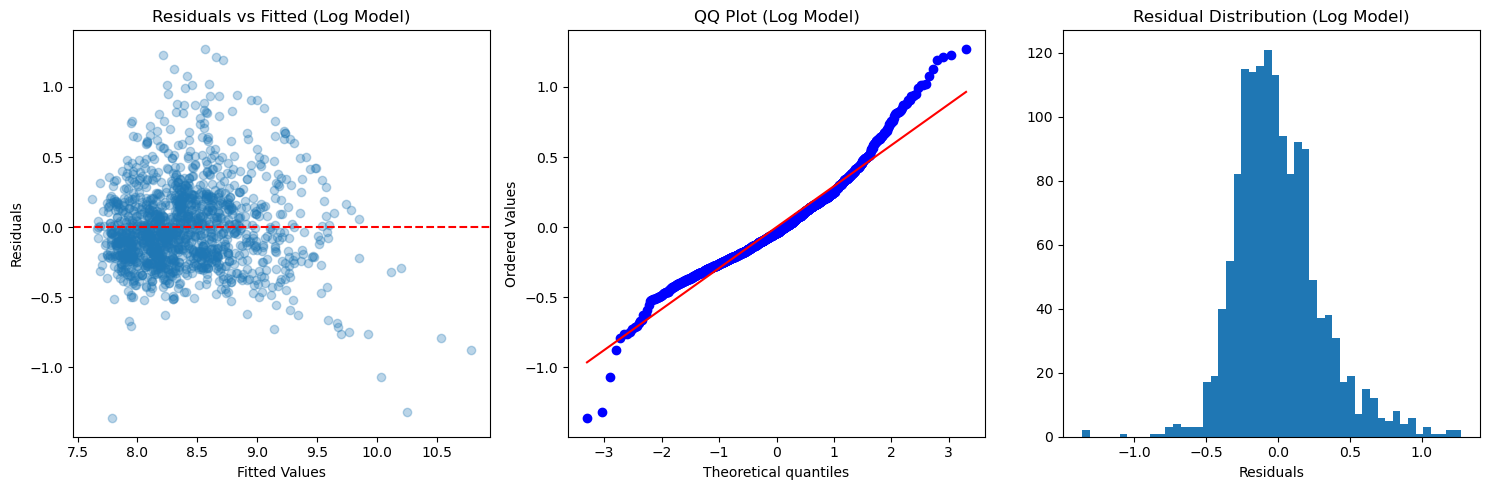

In [18]:
# Diagnostics

fitted_log = log_model.fittedvalues
residuals_log = log_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(fitted_log, residuals_log, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Log Model)')

stats.probplot(residuals_log, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Log Model)')

axes[2].hist(residuals_log, bins=50)
axes[2].set_xlabel('Residuals')
axes[2].set_title('Residual Distribution (Log Model)')

plt.tight_layout()
plt.show()

### Log Model Diagnostics and Interpretation

The log transformation improved the model in several ways:

**R-squared improved from 0.612 to 0.682**, meaning the log model explains more variation in rent than the original model.

**Residuals vs Fitted:** The funnel shape is largely gone — residuals are now much more evenly spread around zero across all fitted values, indicating the heteroscedasticity issue has been substantially reduced.

**QQ Plot:** The points follow the diagonal much more closely compared to the original model, indicating the residuals are closer to normally distributed. There are still a few outliers at the lower tail but this is a significant improvement.

**Residual Distribution:** Much more symmetric and bell-shaped compared to before.

The kurtosis dropped from 10.4 to 4.9, which is still slightly above the normal value of 3 but a major improvement. Overall the log model better satisfies linear regression assumptions and should be preferred over the original model.

Note that coefficients in this model are now interpreted as the percentage change in rent for a one-unit increase in each predictor, rather than a dollar amount.

### Multicollinearity Check

The model flagged a high condition number, suggesting potential multicollinearity. We calculate Variance Inflation Factors (VIF) for each predictor to identify which variables are problematic. A VIF above 10 is generally considered concerning.

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                 feature        VIF
0                  const  48.642059
1                   area   4.156619
2                  baths   3.750623
3                   beds   3.191356
6  medNeighborhoodIncome   1.305707
7              avg_crime   1.171242
4      ucsd_transit_time   1.125220
5       grocery_car_time   1.120136


All predictor variables have VIF values well below 10 which indicates that multicollinearity is not a concern among our chosen predictors. The high VIF for the intercept (const) is expected and not meaningful. The high condition number flagged earlier was therefore likely driven by the scale differences between variables rather than true multicollinearity between predictors.

This gives us confidence that the coefficient estimates in our log model are stable and reliable.

### CHRIS EDITS:

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Train/test split using same variables
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

forest_model.fit(X_train, y_train)

rf_pred = forest_model.predict(X_test)

print("R Squared:", r2_score(y_test, rf_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

R Squared: 0.6351272812960549
Root Mean Squared Error: 2017.0070734530616
Random Forest MAE: 1151.444910762679


We fit a Random Forest regression model for nonlinear relationships since rent may not always increase/decrease linearly with certain variables such as area, beds, etc. 

R squared is 0.635.

RMSE is about 2000. On average, predictors are off by about $2000 

MAE is about 1200. On average, predictors are off by about $1200. 

This isn't too surprising as some units are very overpriced or underpriced for some odd reason.

In [34]:
forest_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

forest_importance

,feature,importance
1,area,0.640167
4,ucsd_transit_time,0.148513
5,grocery_car_time,0.055450
6,medNeighborhoodIncome,0.044775
7,avg_crime,0.040335
3,beds,0.038831
2,baths,0.031929
0,const,0.000000


This shows how important some variables are more influential predictors than others. 

Here, we see that area is a lot more important. So unit size is a major factor. The second most important is ucsd transit time and the rest are less important. 

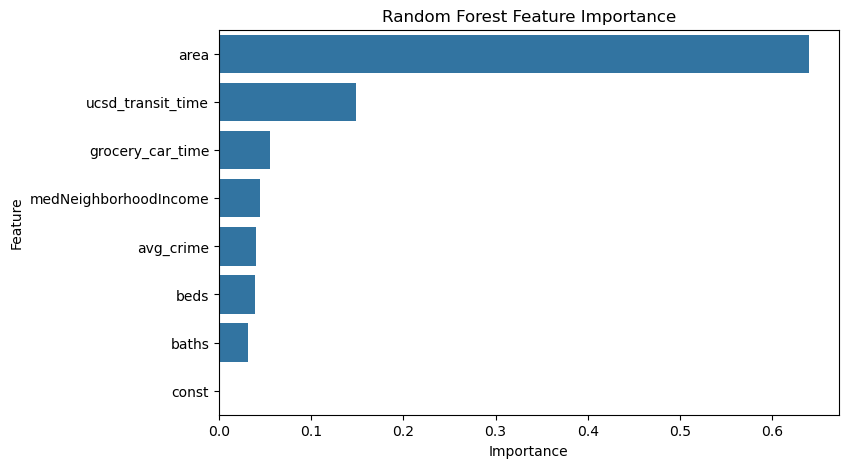

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=forest_importance,
    x="importance",
    y="feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Here's a plot to show the differences of importance in each variable to really see how much area dominates.

In [36]:
import shap

tree_explainer = shap.TreeExplainer(rf_model)
shap_values = tree_explainer.shap_values(X_test)

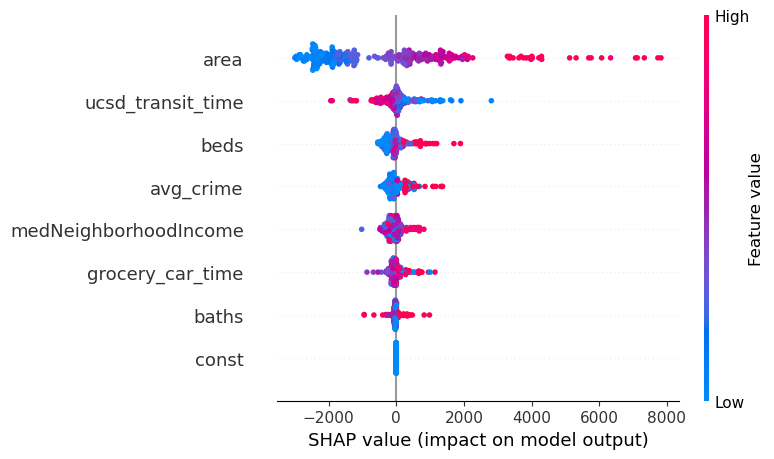

In [37]:
shap.summary_plot(shap_values, X_test)

Additionally, we used SHAP to show how varying values of the variables contribute to the change in rent prices. 

Here, again, we see how much influence area has. Negative and positive extreme values impact the rent prices considerably. Especially in the positive side. UCSD transit time shows the same pattern just not as big. The rest of the variables do the same, however, clearly not as extreme. 


## Conclusions

Our analysis set out to investigate what factors drive rental prices near UCSD and whether proximity to campus commands a price premium...